<div style="background:linear-gradient(135deg,#0f172a 0%,#450a0a 100%);border-radius:16px;padding:40px;border-left:6px solid #ef4444;">
<h1 style="color:#ef4444;font-family:'Segoe UI',sans-serif;margin:0 0 8px;font-size:2.3em;">&#x1F5FB; Adversarial Geology</h1>
<h3 style="color:#cbd5e1;font-family:'Segoe UI',sans-serif;margin:0 0 20px;font-weight:400;">Mapping the Treacherous Decision Surfaces of Neural Networks</h3>
<hr style="border-color:#7f1d1d;"/>
<p style="color:#cbd5e1;font-size:1.05em;line-height:1.85;">
The decision boundary of a neural network in high-dimensional space is not a smooth, gentle slope. It is a jagged, treacherous mountain range where a 1-pixel change can teleport you from a safe plateau to a steep cliff. This notebook maps the <b>decision topography</b> of a classifier in 3D. We train a model on a 2D dataset, generate adversarial examples using <b>FGSM</b> and <b>PGD</b>, and track the exact step-by-step <b>attack trajectories</b> as they crawl across the decision surface and fall off the cliff. Finally, we compare this fragile terrain to an <b>adversarially trained robust model</b>, revealing how robust optimization flattens cliffs into smooth valleys and pushes boundaries far away from data points.
</p>
</div>


## Contents

| # | Section | Description |
|---|---|---|
| 1 | Setup & Configurations | Auto-installs libraries and sets slate dark-theme configurations |
| 2 | Theory: The Geometry of Adversaries | Mathematical formulations of FGSM, PGD, and robust optimization |
| 3 | Dataset: Double Moons | Generate and plot a 2D non-linear classification dataset |
| 4 | MLP Classifier Architecture | Create a 4-layer fully connected network |
| 5 | Standard Model Training | Train the baseline model and evaluate clean accuracy |
| 6 | Adversarial Attack Engines | Implement FGSM and PGD attacks in PyTorch |
| 7 | Mapping the 3D Decision Terrain | Extrapolate a 2D coordinate grid and render the probability surface in 3D |
| 8 | Tracking Attack Trajectories | Calculate and draw the 3D path of an adversarial example falling off the cliff |
| 9 | Robust Optimization (Adversarial Training) | Train a model on adversarial examples and compare robust accuracies |
| 10 | Geological Comparison | Side-by-side 3D visualization of fragile vs. robust decision surfaces |
| 11 | Robustness Radius (2D Bubble Chart) | Find and plot safety margins around clean validation points |
| 12 | Epsilon Sweep Analysis | Plot validation accuracy vs. perturbation size $\epsilon$ for both models |
| 13 | Interactive Geology Scrubber | Control models, starting points, and perturbation size in real-time |
| 14 | Summary & LinkedIn Post Kit | Ready-to-use post templates, hashtags, and visuals checklist |


---
## Section 2 — Theory: The Geometry of Adversaries

### Why Do Adversarial Examples Exist?
Neural networks are mostly linear in their activation pathways (due to ReLUs and linear layers). In high-dimensional space, small perturbations $\delta$ can accumulate along the input dimensions. If we align $\delta$ with the gradient of the loss with respect to the input, we can cause massive changes in output confidence with a very small overall Euclidean norm.

### Fast Gradient Sign Method (FGSM)
FGSM, introduced by Goodfellow et al. (2014), is a single-step adversarial attack that shifts the input in the direction of the sign of the input gradient:

$$x_{\text{adv}} = x + \epsilon \operatorname{sign}\left( \nabla_x \mathcal{L}(\theta, x, y) \right)$$

where $\epsilon$ defines the maximum $L_\infty$ perturbation bound.

### Projected Gradient Descent (PGD)
PGD (Madry et al., 2017) is an iterative, multi-step generalization of FGSM. It takes small steps of size $\alpha$ and projects the result back onto the $L_\infty$ ball (the $\epsilon$-cube) surrounding $x$ after each step:

$$x^{t+1} = \Pi_{x + \mathcal{S}} \left( x^t + \alpha \operatorname{sign}\left( \nabla_{x^t} \mathcal{L}(\theta, x^t, y) \right) \right)$$

where $\mathcal{S} = \{ \delta \mid \|\delta\|_\infty \le \epsilon \}$. PGD is considered the strongest first-order adversary.

### Robust Optimization
To build a robust model, we solve a minimax game, minimizing the maximum possible loss inside the perturbation ball:

$$\min_{\theta} \mathbb{E}_{(x, y) \sim \mathcal{D}} \left[ \max_{\|\delta\|_\infty \le \epsilon} \mathcal{L}(\theta, x + \delta, y) \right]$$

In practice, we approximate this by generating PGD or FGSM examples during training and optimizing the weights to fit those perturbed samples.


In [1]:
!pip install -q torch matplotlib seaborn scikit-learn ipywidgets

import warnings, time, copy
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.datasets import make_moons
import ipywidgets as widgets
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)

BG_COLOR = '#0f172a'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.facecolor': BG_COLOR,
    'figure.facecolor': BG_COLOR, 'axes.edgecolor': '#334155',
    'axes.labelcolor': '#94a3b8', 'xtick.color': '#64748b',
    'ytick.color': '#64748b', 'text.color': '#f1f5f9',
    'grid.color': '#1e293b', 'axes.grid': True, 'grid.alpha': 0.2,
})
print(f'Device: {DEVICE}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 27.9 MB/s eta 0:00:00
Device: cpu


---
## Section 3 — Dataset Creation: Double Moons

We generate a standard 2D double moons dataset. We scale the features to range between $-2.0$ and $2.0$ so that decision surfaces can be cleanly evaluated on a grid and visualized in 3D.


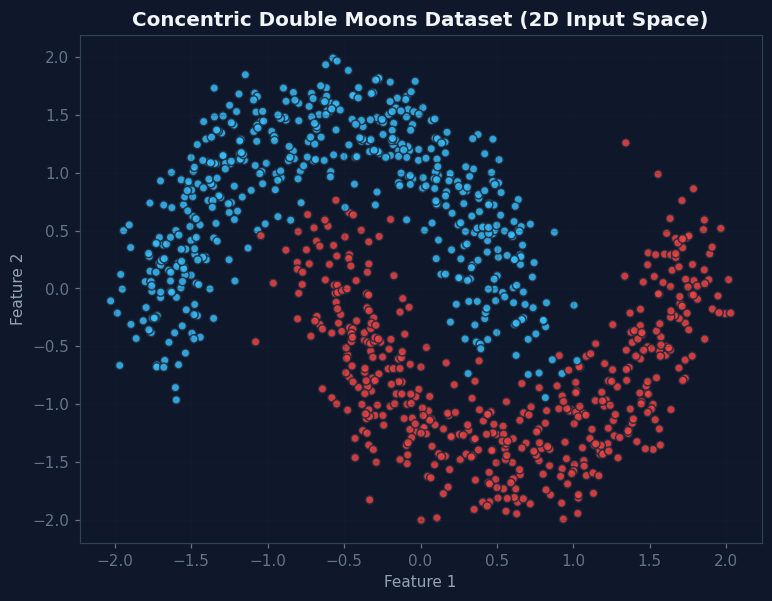

In [2]:
def generate_moons_dataset(num_samples=1200):
    X, Y = make_moons(n_samples=num_samples, noise=0.15, random_state=42)
    # Center and scale data
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    split = int(num_samples * 0.8)
    X_tr = torch.tensor(X[:split], dtype=torch.float32).to(DEVICE)
    X_vl = torch.tensor(X[split:], dtype=torch.float32).to(DEVICE)
    Y_tr = torch.tensor(Y[:split], dtype=torch.long).to(DEVICE)
    Y_vl = torch.tensor(Y[split:], dtype=torch.long).to(DEVICE)

    return X_tr, X_vl, Y_tr, Y_vl

X_train, X_val, Y_train, Y_val = generate_moons_dataset(1200)

# Plot 2D scatter
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#38bdf8' if y == 0 else '#ef4444' for y in Y_train.cpu().numpy()]
ax.scatter(X_train[:, 0].cpu().numpy(), X_train[:, 1].cpu().numpy(), c=colors, s=30, edgecolor='#1e293b', alpha=0.85)
ax.set_title('Concentric Double Moons Dataset (2D Input Space)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
plt.show()


---
## Section 4 — MLP Classifier Architecture

We define a 4-layer fully connected network (MLP) with $64$ hidden units per layer and ReLU activations. This model is deep enough to learn a highly non-linear boundary, which results in interesting decision surfaces.


In [3]:
class SimpleMLP(nn.Module):
    """
    4-layer fully connected network for binary classification.
    """
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.net(x)

model_demo = SimpleMLP()
print(model_demo)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


---
## Section 5 — Standard Model Training

We train the baseline model for $150$ epochs using Adam with a learning rate of $0.005$. We expect the model to achieve $99\%+ $ validation accuracy on clean samples.


In [4]:
def train_standard_model(model, epochs=150, lr=0.005):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs + 1):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            model.eval()
            with torch.no_grad():
                val_acc = (model(X_val).argmax(dim=-1) == Y_val).float().mean().item()
            print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.4f} | Val Acc: {val_acc*100:.1f}%')

model_std = SimpleMLP().to(DEVICE)
train_standard_model(model_std)


Epoch   0 | Train Loss: 0.6928 | Val Acc: 75.8%
Epoch  50 | Train Loss: 0.0220 | Val Acc: 99.6%
Epoch 100 | Train Loss: 0.0193 | Val Acc: 99.2%
Epoch 150 | Train Loss: 0.0185 | Val Acc: 99.2%


---
## Section 6 — Adversarial Attack Engines

We implement the **FGSM** and **PGD** adversarial attack algorithms. Both functions compute the gradient of the cross-entropy loss with respect to the input tensor and update the inputs. PGD projects the perturbation back onto the $L_\infty$ ball of radius $\epsilon$ at each iteration.


In [5]:
def fgsm_attack(model, x, y, epsilon, criterion):
    # Ensure inputs request gradients
    x_adv = x.clone().detach().requires_grad_(True)
    outputs = model(x_adv)
    loss = criterion(outputs, y)
    model.zero_grad()
    loss.backward()

    # Step along gradient direction
    x_adv = x_adv + epsilon * x_adv.grad.sign()
    return x_adv.detach()

def pgd_attack(model, x, y, epsilon, alpha, num_steps, criterion):
    # Initialize with random noise inside the L-infinity ball
    x_adv = x.clone().detach() + torch.empty_like(x).uniform_(-epsilon, epsilon)
    x_adv = torch.clamp(x_adv, x - epsilon, x + epsilon).detach().requires_grad_(True)

    for _ in range(num_steps):
        outputs = model(x_adv)
        loss = criterion(outputs, y)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            # Gradient descent step to maximize loss
            x_adv = x_adv + alpha * x_adv.grad.sign()
            # Project back onto L-infinity ball
            x_adv = torch.max(torch.min(x_adv, x + epsilon), x - epsilon)

        x_adv = x_adv.detach().requires_grad_(True)

    return x_adv.detach()

criterion = nn.CrossEntropyLoss()
# Evaluate baseline model on clean vs adversarial data
X_adv_std = pgd_attack(model_std, X_val, Y_val, epsilon=0.4, alpha=0.08, num_steps=12, criterion=criterion)
with torch.no_grad():
    clean_acc = (model_std(X_val).argmax(dim=-1) == Y_val).float().mean().item()
    adv_acc = (model_std(X_adv_std).argmax(dim=-1) == Y_val).float().mean().item()

print(f'Standard model clean accuracy: {clean_acc*100:.1f}%')
print(f'Standard model PGD-12 accuracy (epsilon=0.4): {adv_acc*100:.1f}%')


Standard model clean accuracy: 99.2%
Standard model PGD-12 accuracy (epsilon=0.4): 63.7%


---
## Section 7 — Mapping the 3D Decision Terrain

To visualize the decision surface, we generate an $80 \times 80$ uniform grid of coordinates covering range $[-2.5, 2.5]$ in both axes. We evaluate the model's confidence ($P(\text{class } 1)$ via Softmax) at each grid coordinate, and plot this probability as height $Z$ in 3D. Class 0 points are colored blue, Class 1 points are colored red.


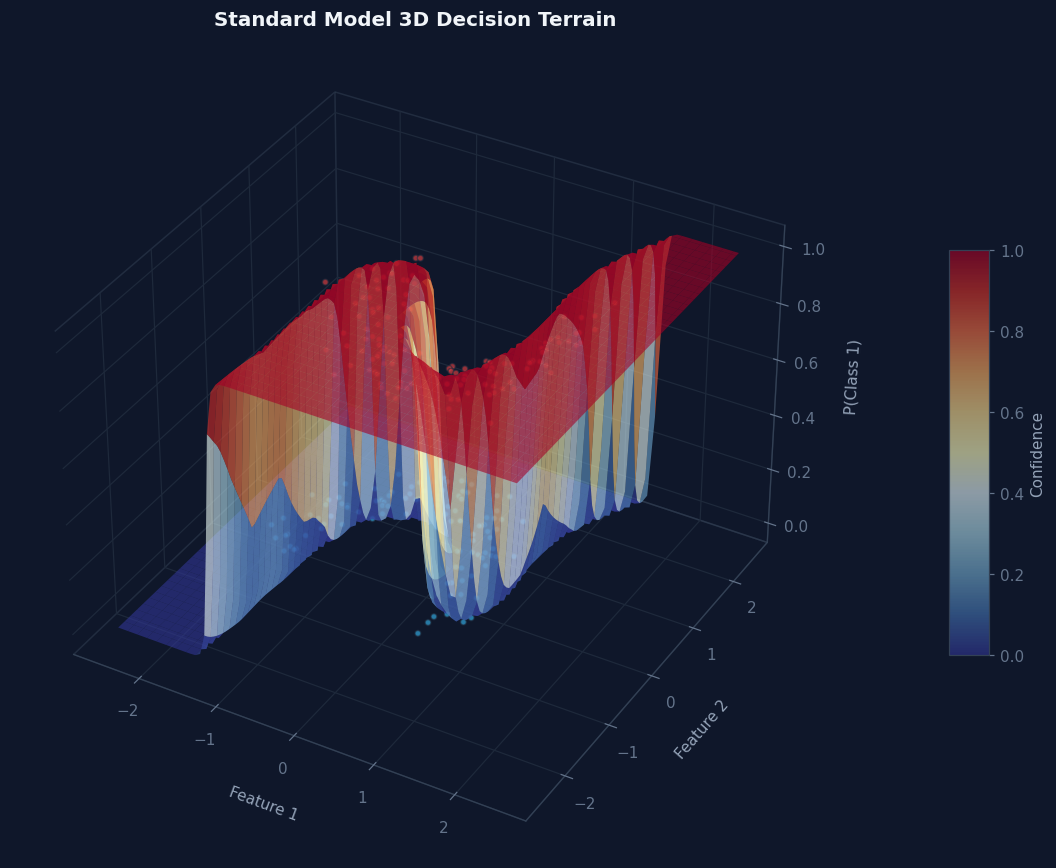

In [6]:
def plot_decision_surface_3d(model, X, Y, trajectory=None, title='Decision Surface'):
    # Extrapolate grid
    grid_x = np.linspace(-2.5, 2.5, 80)
    grid_y = np.linspace(-2.5, 2.5, 80)
    xx, yy = np.meshgrid(grid_x, grid_y)

    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(grid_tensor)
        probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy().reshape(xx.shape)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot surface terrain
    surf = ax.plot_surface(xx, yy, probs, cmap='RdYlBu_r', alpha=0.6, edgecolor='none', zorder=1)

    # Plot validation points at their 2D locations (Z corresponds to actual label: 0 or 1)
    X_np = X.cpu().numpy()
    Y_np = Y.cpu().numpy()
    colors = ['#38bdf8' if y == 0 else '#ef4444' for y in Y_np]
    ax.scatter(X_np[:, 0], X_np[:, 1], Y_np, c=colors, s=15, edgecolor='#1e293b', alpha=0.6, zorder=5)

    if trajectory is not None:
        # Trajectory shows path of attack: columns (x, y, probability)
        ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], color='#e11d48', lw=4, marker='o', ms=6, zorder=10, label='PGD Path')
        ax.text(trajectory[0, 0], trajectory[0, 1], trajectory[0, 2] + 0.05, 'Start', color='#22c55e', fontweight='bold', zorder=11)
        ax.text(trajectory[-1, 0], trajectory[-1, 1], trajectory[-1, 2] + 0.05, 'FOOLED!', color='#f43f5e', fontweight='bold', zorder=11)
        ax.legend(facecolor='#1e293b')

    ax.set_xlabel('Feature 1', labelpad=10)
    ax.set_ylabel('Feature 2', labelpad=10)
    ax.set_zlabel('P(Class 1)', labelpad=10)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.view_init(elev=35, azim=-60)

    # Customizing panels to match dark theme
    ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#334155'); ax.yaxis.pane.set_edgecolor('#334155'); ax.zaxis.pane.set_edgecolor('#334155')

    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1, label='Confidence')
    plt.tight_layout()
    plt.show()

plot_decision_surface_3d(model_std, X_val, Y_val, title='Standard Model 3D Decision Terrain')


---
## Section 8 — Tracking Attack Trajectories

We implement `track_pgd_trajectory` to select a single, correctly classified validation sample, run PGD, and log the coordinates and prediction probability at each step. We plot the trajectory on the 3D surface. Observe how the point starts in a safe region ($P \approx 1.0$), is pushed across the decision boundary by the gradient steps, and falls off the cliff into the incorrect region ($P \approx 0.0$).


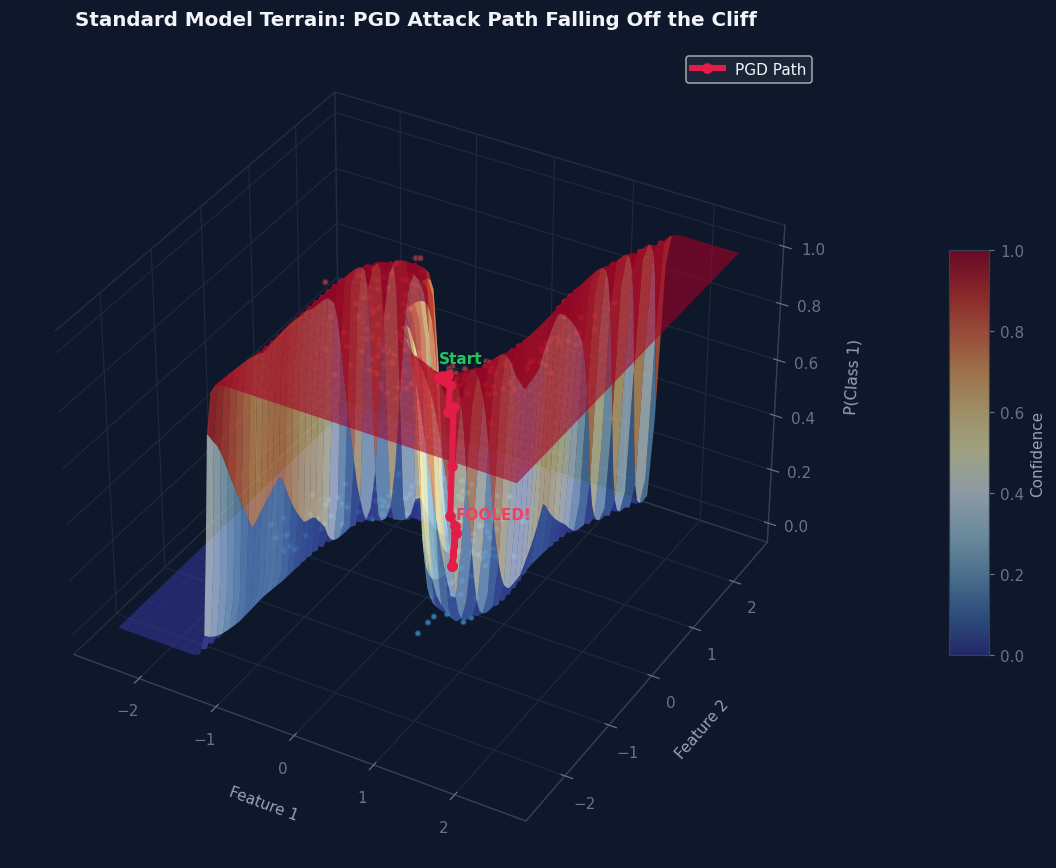

In [7]:
def track_pgd_trajectory(model, x_start, y_start, epsilon=0.5, alpha=0.04, steps=15):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    x = x_start.clone().detach().unsqueeze(0).requires_grad_(True)
    y = y_start.unsqueeze(0)

    trajectory = []

    # Record initial position
    with torch.no_grad():
        p_curr = F.softmax(model(x), dim=-1)[0, 1].item()
    trajectory.append([x[0, 0].item(), x[0, 1].item(), p_curr])

    for _ in range(steps):
        outputs = model(x)
        loss = criterion(outputs, y)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            # Move along gradient direction to maximize loss
            x_next = x + alpha * x.grad.sign()
            # Project back onto L-infinity ball around start point
            delta = x_next - x_start.unsqueeze(0)
            delta = torch.clamp(delta, -epsilon, epsilon)
            x_next = x_start.unsqueeze(0) + delta

        x = x_next.clone().detach().requires_grad_(True)

        with torch.no_grad():
            p_curr = F.softmax(model(x), dim=-1)[0, 1].item()
        trajectory.append([x[0, 0].item(), x[0, 1].item(), p_curr])

    return np.array(trajectory)

# Find a point that standard model classifies correctly with high confidence (say, Class 1 -> p > 0.95)
model_std.eval()
with torch.no_grad():
    probs = F.softmax(model_std(X_val), dim=-1)[:, 1]
    correct_class1 = ((probs > 0.95) & (Y_val == 1)).nonzero(as_tuple=True)[0]

start_idx = correct_class1[0].item() # Select first valid index
x_start = X_val[start_idx]
y_start = Y_val[start_idx]

trajectory = track_pgd_trajectory(model_std, x_start, y_start, epsilon=0.45, alpha=0.04, steps=15)
plot_decision_surface_3d(model_std, X_val, Y_val, trajectory=trajectory,
                         title='Standard Model Terrain: PGD Attack Path Falling Off the Cliff')


---
## Section 9 — Robust Optimization (Adversarial Training)

We train a new model using **Adversarial Training**. During each epoch, we use FGSM to generate adversarial examples from the training set, and train the model to minimize loss on these perturbed samples. We verify that this model is robust to adversarial attacks.


In [9]:
def train_adversarial_model(model, epochs=150, lr=0.005, epsilon=0.25):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs + 1):
        model.train()
        # Generate FGSM adversarial examples for training batch
        X_adv_train = fgsm_attack(model, X_train, Y_train, epsilon, criterion)

        outputs = model(X_adv_train)
        loss = criterion(outputs, Y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            model.eval()
            with torch.no_grad():
                clean_acc = (model(X_val).argmax(dim=-1) == Y_val).float().mean().item()
            print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.4f} | Clean Val Acc: {clean_acc*100:.1f}%')

model_robust = SimpleMLP().to(DEVICE)
train_adversarial_model(model_robust)

# Evaluate robust model under PGD attack
X_adv_rob = pgd_attack(model_robust, X_val, Y_val, epsilon=0.4, alpha=0.08, num_steps=12, criterion=criterion)
with torch.no_grad():
    rob_clean_acc = (model_robust(X_val).argmax(dim=-1) == Y_val).float().mean().item()
    rob_adv_acc = (model_robust(X_adv_rob).argmax(dim=-1) == Y_val).float().mean().item()

print(f'\nRobust Model clean accuracy: {rob_clean_acc*100:.1f}%')
print(f'Robust Model PGD-12 accuracy (epsilon=0.4): {rob_adv_acc*100:.1f}%')

Epoch   0 | Train Loss: 0.7038 | Clean Val Acc: 88.7%
Epoch  50 | Train Loss: 0.2560 | Clean Val Acc: 97.1%
Epoch 100 | Train Loss: 0.2482 | Clean Val Acc: 96.2%
Epoch 150 | Train Loss: 0.2464 | Clean Val Acc: 96.2%

Robust Model clean accuracy: 96.2%
Robust Model PGD-12 accuracy (epsilon=0.4): 77.1%


---
## Section 10 — Geological Comparison

We compare the 3D decision terrain of the Standard Model and the Adversarially Trained Model side-by-side. Observe how standard training results in sharp, vertical cliffs close to the training data. In contrast, adversarial training creates **gentle, smooth slopes**, pushing the transition boundaries far away from the data clusters and providing a safety buffer.


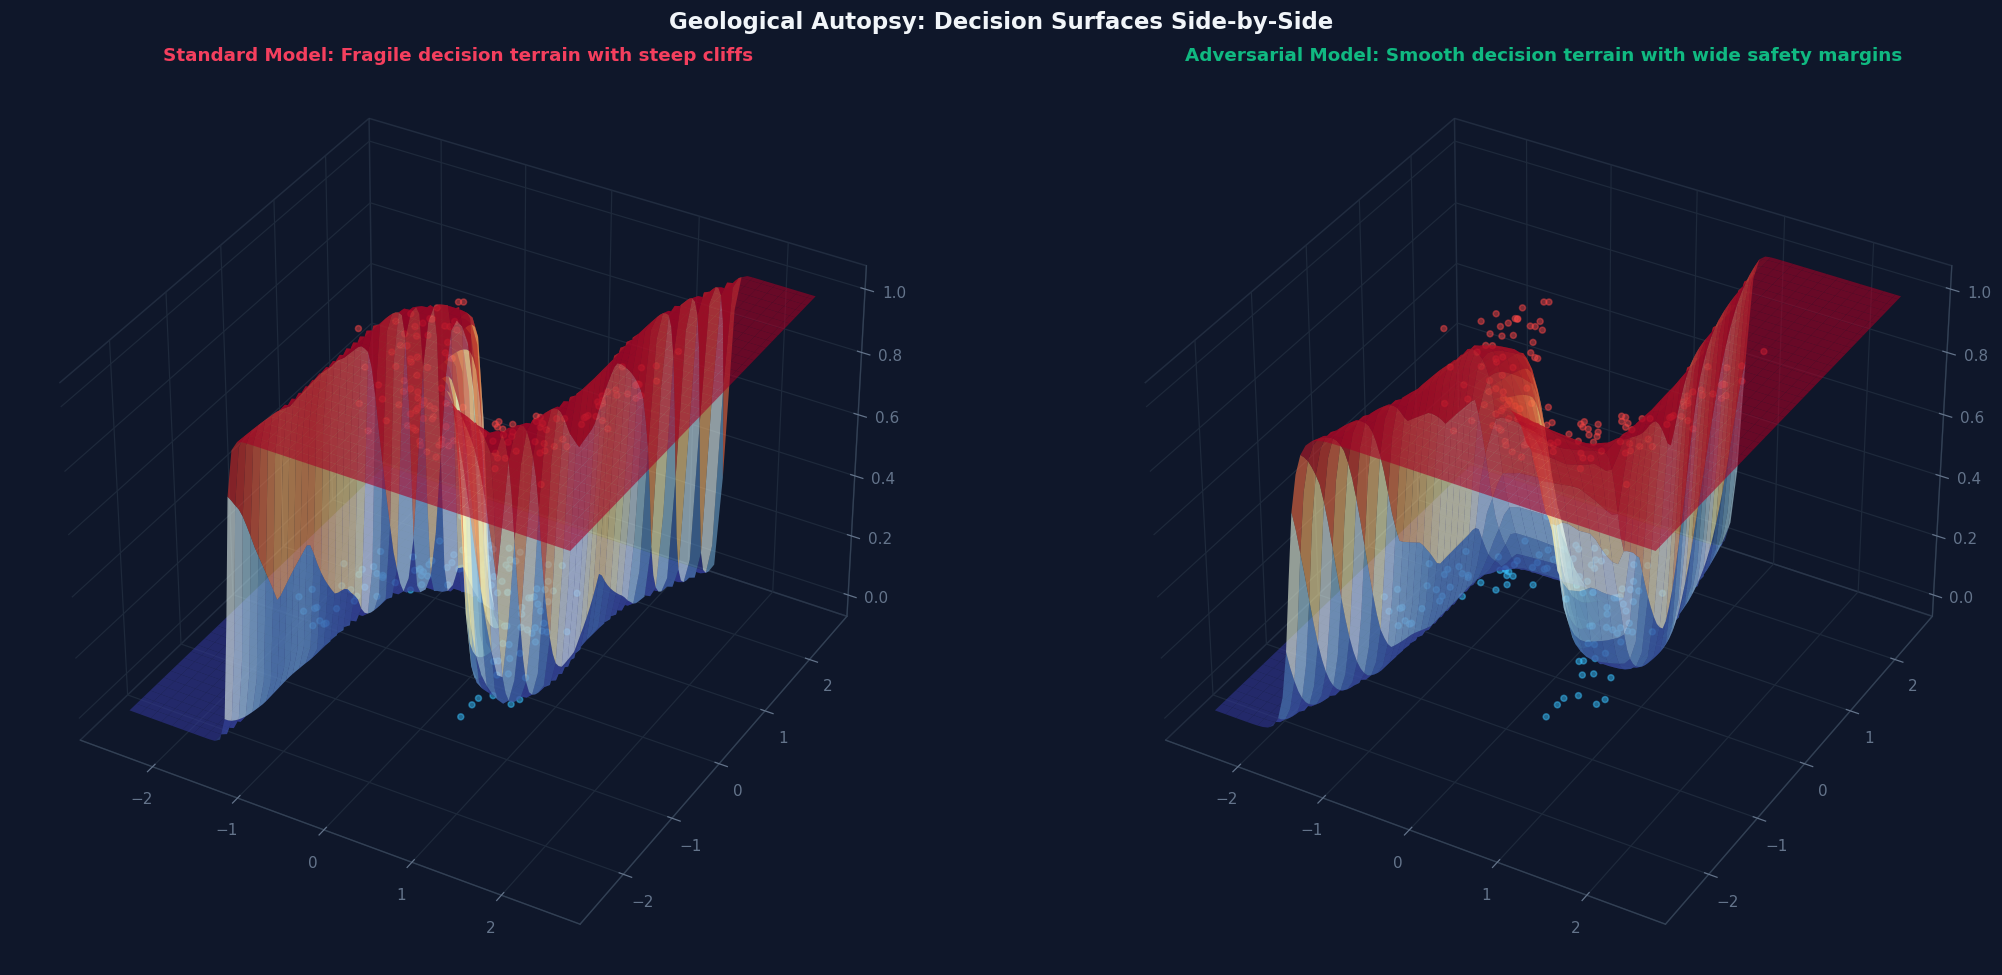

In [10]:
fig = plt.figure(figsize=(20, 9))

grid_x = np.linspace(-2.5, 2.5, 80)
grid_y = np.linspace(-2.5, 2.5, 80)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(DEVICE)

# ── Standard Model Terrain ───────────────────────────────────────────────────
model_std.eval()
with torch.no_grad():
    probs_std = F.softmax(model_std(grid_tensor), dim=-1)[:, 1].cpu().numpy().reshape(xx.shape)

ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(xx, yy, probs_std, cmap='RdYlBu_r', alpha=0.6, edgecolor='none')
colors = ['#38bdf8' if y == 0 else '#ef4444' for y in Y_val.cpu().numpy()]
ax1.scatter(X_val.cpu().numpy()[:, 0], X_val.cpu().numpy()[:, 1], Y_val.cpu().numpy(), c=colors, s=15, alpha=0.5)
ax1.set_title('Standard Model: Fragile decision terrain with steep cliffs', fontsize=12, fontweight='bold', color='#f43f5e')
ax1.view_init(elev=35, azim=-60)
ax1.xaxis.pane.fill = False; ax1.yaxis.pane.fill = False; ax1.zaxis.pane.fill = False
ax1.xaxis.pane.set_edgecolor('#334155'); ax1.yaxis.pane.set_edgecolor('#334155'); ax1.zaxis.pane.set_edgecolor('#334155')

# ── Robust Model Terrain ─────────────────────────────────────────────────────
model_robust.eval()
with torch.no_grad():
    probs_rob = F.softmax(model_robust(grid_tensor), dim=-1)[:, 1].cpu().numpy().reshape(xx.shape)

ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(xx, yy, probs_rob, cmap='RdYlBu_r', alpha=0.6, edgecolor='none')
ax2.scatter(X_val.cpu().numpy()[:, 0], X_val.cpu().numpy()[:, 1], Y_val.cpu().numpy(), c=colors, s=15, alpha=0.5)
ax2.set_title('Adversarial Model: Smooth decision terrain with wide safety margins', fontsize=12, fontweight='bold', color='#10b981')
ax2.view_init(elev=35, azim=-60)
ax2.xaxis.pane.fill = False; ax2.yaxis.pane.fill = False; ax2.zaxis.pane.fill = False
ax2.xaxis.pane.set_edgecolor('#334155'); ax2.yaxis.pane.set_edgecolor('#334155'); ax2.zaxis.pane.set_edgecolor('#334155')

plt.suptitle('Geological Autopsy: Decision Surfaces Side-by-Side', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


---
## Section 11 — Robustness Radius (2D Bubble Chart)

For each point in a validation sample, we calculate its **Robustness Radius**. This is the distance to the nearest decision boundary. We trace along the gradient sign step-by-step until the model's prediction flips. We plot the points in 2D, surrounding them with a shaded bubble whose size matches this boundary distance.

Observe that standard training yields tiny, almost invisible bubbles, meaning the decision boundary crowds the data. Adversarial training produces large, overlapping bubbles, verifying a wide margin of safety.


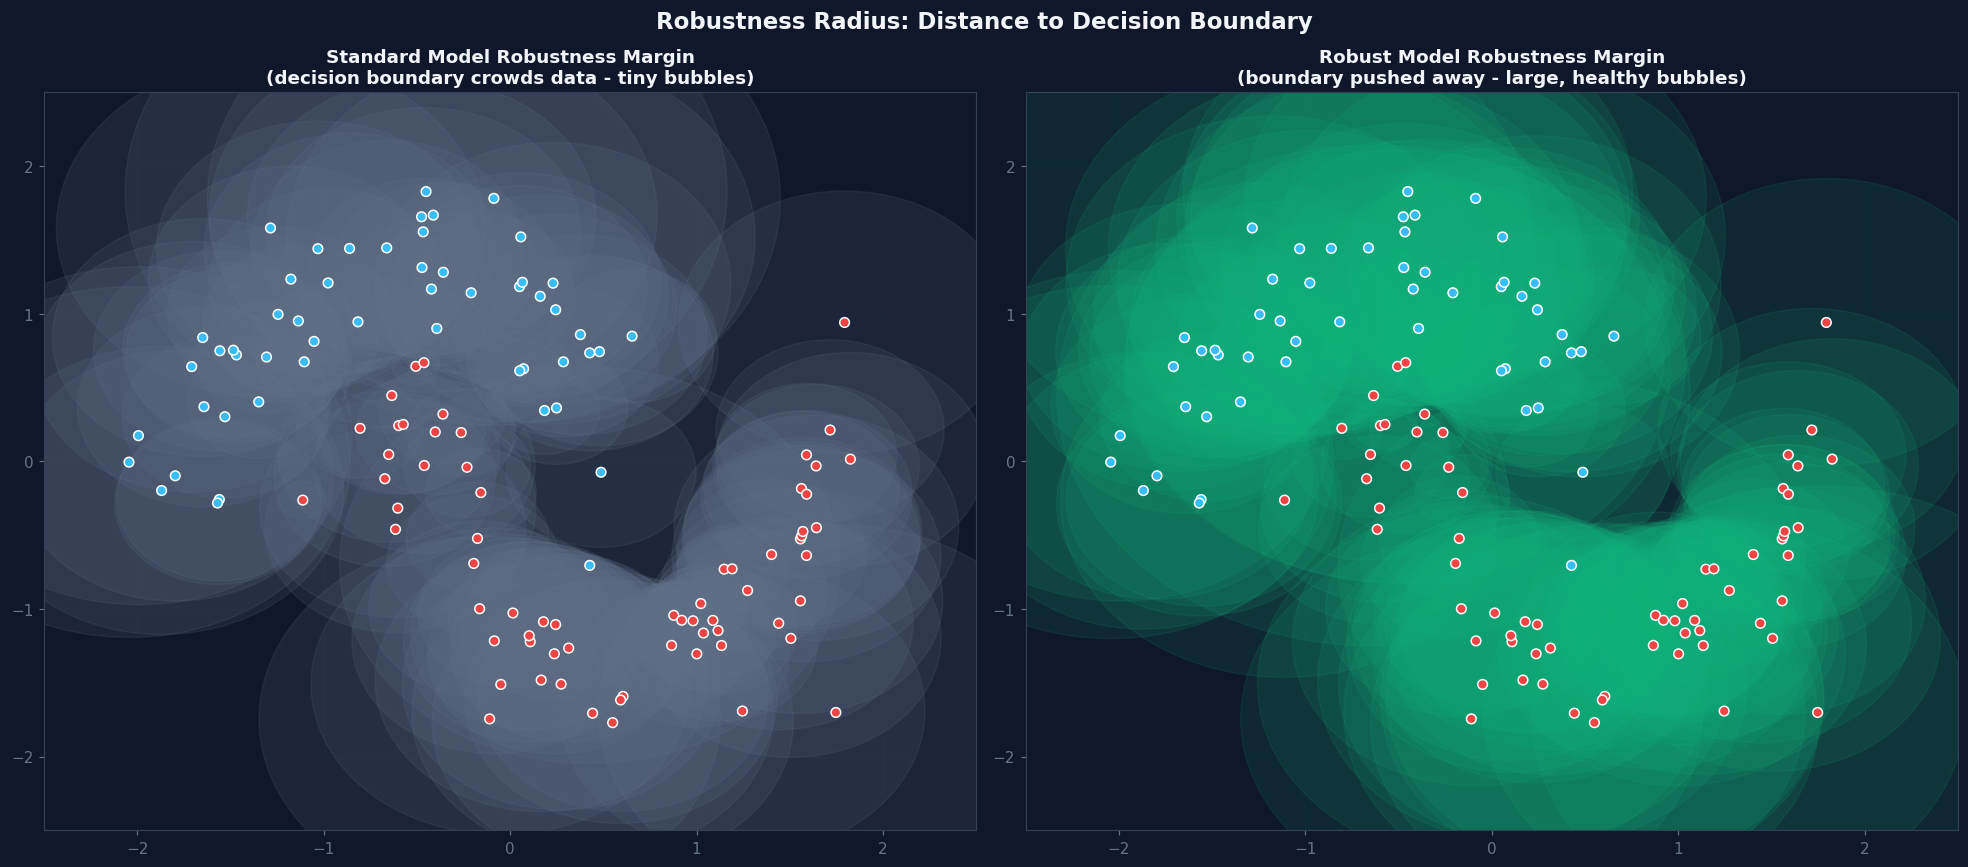

In [12]:
def compute_robustness_radius(model, x, y, max_steps=40, step_size=0.03):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    x_orig = x.clone().detach()
    x_curr = x.clone().detach().unsqueeze(0).requires_grad_(True)
    y_target = y.unsqueeze(0)

    with torch.no_grad():
        init_class = model(x_curr).argmax(dim=-1).item()

    for _ in range(max_steps):
        outputs = model(x_curr)
        pred_class = outputs.argmax(dim=-1).item()

        if pred_class != init_class:
            # Class flipped! Return distance
            return torch.norm(x_curr.squeeze(0) - x_orig).item()

        loss = criterion(outputs, y_target)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            x_next = x_curr + step_size * x_curr.grad.sign()
        x_curr = x_next.clone().detach().requires_grad_(True)

    return torch.norm(x_curr.squeeze(0) - x_orig).item()

# Sample 120 validation points for clean bubbles plot
np.random.seed(42)
sample_idx = np.random.choice(len(X_val), 120, replace=False)
X_sample = X_val[sample_idx]
Y_sample = Y_val[sample_idx]

std_radii = [compute_robustness_radius(model_std, X_sample[i], Y_sample[i]) for i in range(120)]
rob_radii = [compute_robustness_radius(model_robust, X_sample[i], Y_sample[i]) for i in range(120)]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
colors_samp = ['#38bdf8' if y == 0 else '#ef4444' for y in Y_sample.cpu().numpy()]

# 1. Standard Model
axes[0].scatter(X_sample.cpu().numpy()[:, 0], X_sample.cpu().numpy()[:, 1], c=colors_samp, s=40, edgecolor='white', zorder=5)
for i in range(120):
    axes[0].add_patch(plt.Circle((X_sample[i, 0].item(), X_sample[i, 1].item()), std_radii[i],
                                 fill=True, color='#64748b', alpha=0.15, zorder=2))
axes[0].set_title('Standard Model Robustness Margin\n(decision boundary crowds data - tiny bubbles)', fontsize=12, fontweight='bold')
axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5)

# 2. Robust Model
axes[1].scatter(X_sample.cpu().numpy()[:, 0], X_sample.cpu().numpy()[:, 1], c=colors_samp, s=40, edgecolor='white', zorder=5)
for i in range(120):
    axes[1].add_patch(plt.Circle((X_sample[i, 0].item(), X_sample[i, 1].item()), rob_radii[i],
                                 fill=True, color='#10b981', alpha=0.10, zorder=2))
axes[1].set_title('Robust Model Robustness Margin\n(boundary pushed away - large, healthy bubbles)', fontsize=12, fontweight='bold')
axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5)

plt.suptitle('Robustness Radius: Distance to Decision Boundary', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

---
## Section 12 — Epsilon Sweep Analysis

We sweep the perturbation size $\epsilon$ from $0.0$ to $0.6$ and measure validation accuracies under PGD attacks for both models. This plots the robustness profile of the networks.


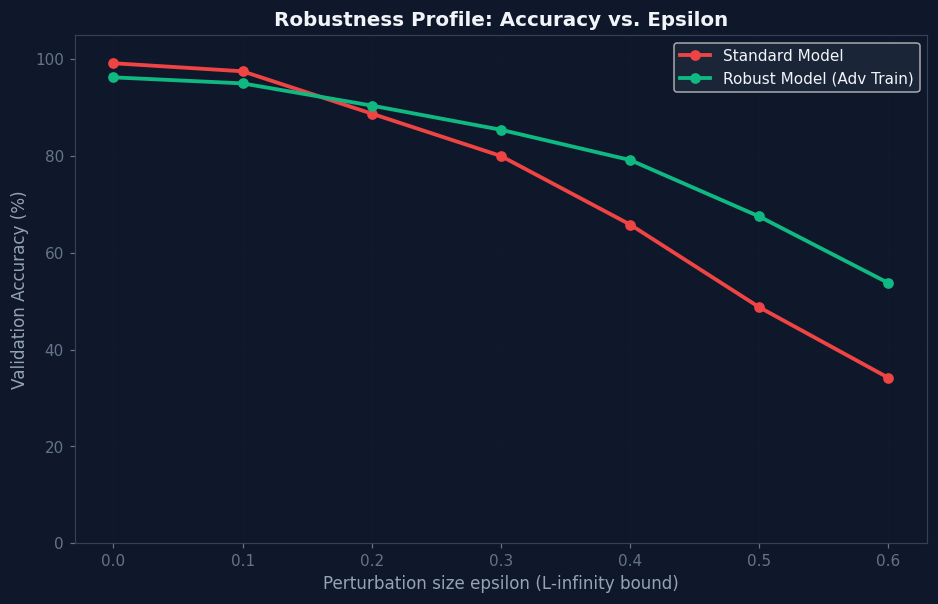

In [13]:
epsilons = np.linspace(0.0, 0.6, 7)
std_accs = []
rob_accs = []

for eps in epsilons:
    if eps == 0.0:
        with torch.no_grad():
            std_accs.append((model_std(X_val).argmax(dim=-1) == Y_val).float().mean().item())
            rob_accs.append((model_robust(X_val).argmax(dim=-1) == Y_val).float().mean().item())
    else:
        # Run PGD
        X_adv_s = pgd_attack(model_std, X_val, Y_val, epsilon=eps, alpha=eps/5, num_steps=10, criterion=criterion)
        X_adv_r = pgd_attack(model_robust, X_val, Y_val, epsilon=eps, alpha=eps/5, num_steps=10, criterion=criterion)

        with torch.no_grad():
            std_accs.append((model_std(X_adv_s).argmax(dim=-1) == Y_val).float().mean().item())
            rob_accs.append((model_robust(X_adv_r).argmax(dim=-1) == Y_val).float().mean().item())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epsilons, [a*100 for a in std_accs], color='#ef4444', marker='o', lw=2.5, label='Standard Model')
ax.plot(epsilons, [a*100 for a in rob_accs], color='#10b981', marker='o', lw=2.5, label='Robust Model (Adv Train)')

ax.set_xlabel('Perturbation size epsilon (L-infinity bound)', fontsize=11)
ax.set_ylabel('Validation Accuracy (%)', fontsize=11)
ax.set_title('Robustness Profile: Accuracy vs. Epsilon', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(facecolor='#1e293b')
plt.show()


---
## Section 13 — Interactive Geology Scrubber

Use the dashboard below to interactively explore decision topography. Select between the Standard and Robust models, select a starting point index from the validation set, adjust epsilon, and click update. The tool outputs the 3D surface plot and tracks the step-by-step PGD attack path in real time.


In [14]:
def update_interactive_geology(model_type, start_idx, epsilon, azim_angle):
    target_model = model_std if model_type == 'Standard' else model_robust

    x_s = X_val[start_idx]
    y_s = Y_val[start_idx]

    # Track trajectory
    trajectory = track_pgd_trajectory(target_model, x_s, y_s, epsilon=epsilon, alpha=epsilon/7 if epsilon > 0 else 0, steps=12)

    # Render
    grid_x = np.linspace(-2.5, 2.5, 80)
    grid_y = np.linspace(-2.5, 2.5, 80)
    xx, yy = np.meshgrid(grid_x, grid_y)
    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(DEVICE)

    target_model.eval()
    with torch.no_grad():
        logits = target_model(grid_tensor)
        probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy().reshape(xx.shape)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Decision terrain
    surf = ax.plot_surface(xx, yy, probs, cmap='RdYlBu_r', alpha=0.6, edgecolor='none', zorder=1)

    # Validation points sample
    X_np = X_val.cpu().numpy()
    Y_np = Y_val.cpu().numpy()
    colors = ['#38bdf8' if y == 0 else '#ef4444' for y in Y_np]
    ax.scatter(X_np[:, 0], X_np[:, 1], Y_np, c=colors, s=15, alpha=0.4, zorder=5)

    # Trajectory path
    ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], color='#e11d48', lw=4.5, marker='o', ms=6, zorder=10, label='PGD Path')
    ax.text(trajectory[0, 0], trajectory[0, 1], trajectory[0, 2] + 0.05, 'Start', color='#22c55e', fontweight='bold', zorder=11)

    # Class flip validation
    final_p = trajectory[-1, 2]
    init_p = trajectory[0, 2]
    init_pred = 1 if init_p >= 0.5 else 0
    final_pred = 1 if final_p >= 0.5 else 0
    is_fooled = init_pred != final_pred

    status_text = 'FOOLED! (Crossed boundary)' if is_fooled else 'Held! (Resisted attack)'
    status_color = '#f43f5e' if is_fooled else '#10b981'

    ax.text(trajectory[-1, 0], trajectory[-1, 1], trajectory[-1, 2] + 0.05, status_text, color=status_color, fontweight='bold', zorder=11)

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('P(Class 1)')
    ax.set_title(f'{model_type} Model decision Surface\n'
                 f'PGD Trajectory starting at index {start_idx} | Status: {status_text}',
                 fontsize=12, fontweight='bold')
    ax.view_init(elev=35, azim=azim_angle)
    ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#334155'); ax.yaxis.pane.set_edgecolor('#334155'); ax.zaxis.pane.set_edgecolor('#334155')

    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
    plt.tight_layout()
    plt.show()

widgets.interact(
    update_interactive_geology,
    model_type=widgets.Dropdown(options=['Standard', 'Robust'], value='Standard', description='Model:'),
    start_idx=widgets.IntSlider(value=0, min=0, max=len(X_val)-1, step=1, description='Point Index:', layout=widgets.Layout(width='50%')),
    epsilon=widgets.FloatSlider(value=0.4, min=0.0, max=0.8, step=0.05, description='Epsilon:', layout=widgets.Layout(width='50%')),
    azim_angle=widgets.IntSlider(value=-60, min=-180, max=180, step=10, description='Rotate View:', layout=widgets.Layout(width='50%'))
)


interactive(children=(Dropdown(description='Model:', options=('Standard', 'Robust'), value='Standard'), IntSli…

<function __main__.update_interactive_geology(model_type, start_idx, epsilon, azim_angle)>